In [ ]:
# I'll run a full, end-to-end LSTM modelling pipeline on your uploaded file:
# - Load and inspect the CSV
# - Perform thorough EDA (summary stats, missing values, plots, autocorrelation)
# - Preprocess (date parsing, resampling if needed, imputation, scaling)
# - Create sequences for LSTM
# - Automatic hyperparameter tuning via randomized search (training multiple LSTM configs)
# - Train, evaluate, save best model and scalers
# - Load saved model and produce next-step predictions (recursive multi-step forecast)
# - Save outputs to /mnt/data and provide links
#
# Notes:
# - Plots use matplotlib only (no seaborn) as requested.
# - The tuning procedure is a randomized search implemented in-Python (no external tuner required).
# - If any package is missing the run will attempt to continue gracefully and report it.
#
# Let's begin.
import os
import random
import pickle
import math
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


print("TensorFlow version:", tf.__version__)

csv_path = 'Tiruppur_RFD.csv'
assert os.path.exists(csv_path), f"CSV file not found at {csv_path}"

TensorFlow version: 2.19.0


In [ ]:
# -----------------------
# 1) Load and inspect
# -----------------------
df = pd.read_csv(csv_path)
print("\n--- File loaded ---\nRows: {}, Columns: {}\n".format(df.shape[0], df.shape[1]))
print("First 10 rows:")
display(df.head(10))

print("\nData types and non-null counts:")
print(df.info())

print("\nSummary statistics (numeric columns):")
display(df.describe())

# Check missing values
nulls = df.isnull().sum().sort_values(ascending=False)
print("\nMissing values per column (descending):")
print(nulls[nulls>0])


--- File loaded ---
Rows: 7792, Columns: 4

First 10 rows:


,dist,station,value,date
0,Tiruppur,Udumalpet,7.6,28-01-2007
1,Tiruppur,Palladam,4.2,28-01-2007
2,Tiruppur,Avinashi,1.0,28-01-2007
3,Tiruppur,Avinashi,2.0,18-02-2007
4,Tiruppur,Udumalpet,49.0,15-04-2007
5,Tiruppur,District Collector Office,5.0,15-04-2007
6,Tiruppur,Palladam,3.2,15-04-2007
7,Tiruppur,Udumalpet,4.0,16-04-2007
8,Tiruppur,Kangeyam,65.4,19-04-2007
9,Tiruppur,Avinashi,27.0,19-04-2007



Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7792 entries, 0 to 7791
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dist     7792 non-null   object 
 1   station  7792 non-null   object 
 2   value    7792 non-null   float64
 3   date     7792 non-null   object 
dtypes: float64(1), object(3)
memory usage: 243.6+ KB
None

Summary statistics (numeric columns):


,value
count,7792.000000
mean,14.248985
std,18.908733
min,0.020000
25%,3.000000
50%,7.000000
75%,18.000000
max,273.000000



Missing values per column (descending):
Series([], dtype: int64)


In [ ]:
# -----------------------
# 2) Try to detect a date/time column
# -----------------------
date_col = None
for col in df.columns:
    # Heuristic: column name contains 'date' or 'time' or dtype object but parseable
    if 'date' in col.lower() or 'time' in col.lower() or 'timestamp' in col.lower():
        date_col = col
        break

if date_col is None:
    # Try to find a column that looks parseable
    for col in df.columns:
        if df[col].dtype == object:
            sample = df[col].dropna().astype(str).iloc[:10].tolist()
            parseable = True
            for s in sample:
                try:
                    pd.to_datetime(s)
                except Exception:
                    parseable = False
                    break
            if parseable and len(sample)>0:
                date_col = col
                break

print("\nDetected date column:", date_col)

if date_col is not None:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.sort_values(date_col).reset_index(drop=True)
    print(f"\nAfter parsing, date range: {df[date_col].min()} to {df[date_col].max()}")
else:
    print("No obvious date column found; we'll treat this as a plain tabular dataset.")


Detected date column: date

After parsing, date range: 2007-01-28 00:00:00 to 2023-12-25 00:00:00


/tmp/ipython-input-3949422516.py:30: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')



Numeric columns detected: ['value']
Selected primary target for time-series analysis: value


<Figure size 1000x400 with 0 Axes>

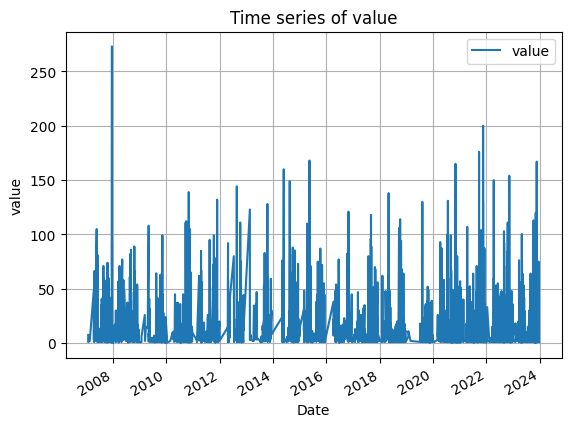

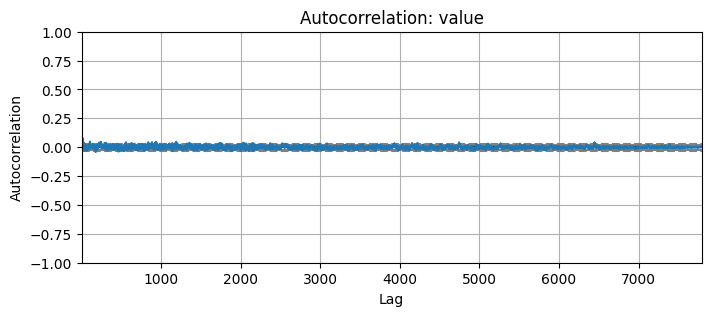


Top correlations (absolute) with the primary target:


,value
value,1.0


In [ ]:
# -----------------------
# 3) EDA - plots and autocorrelation (if numeric/time series)
# -----------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns detected:", numeric_cols)

# If there is a date column and at least one numeric column, do time-series EDA
plt.figure(figsize=(10,4))
if date_col is not None and len(numeric_cols)>0:
    target_col = numeric_cols[0]  # choose first numeric as primary target
    print("Selected primary target for time-series analysis:", target_col)
    df_plot = df[[date_col, target_col]].set_index(date_col)
    df_plot.plot(title=f"Time series of {target_col}")
    plt.xlabel("Date")
    plt.ylabel(target_col)
    plt.grid(True)
    plt.show()
else:
    # plot histograms for numeric columns
    for col in numeric_cols:
        plt.figure(figsize=(6,3))
        plt.hist(df[col].dropna(), bins=50)
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

# basic autocorrelation plot for primary numeric column
if len(numeric_cols)>0:
    from pandas.plotting import autocorrelation_plot
    plt.figure(figsize=(8,3))
    autocorrelation_plot(df[numeric_cols[0]].dropna())
    plt.title(f"Autocorrelation: {numeric_cols[0]}")
    plt.show()

# show correlation matrix (heatmap not used; print strong correlations)
corr = df[numeric_cols].corr()
print("\nTop correlations (absolute) with the primary target:")
if len(numeric_cols)>0:
    primary = numeric_cols[0]
    corrs_with_primary = corr[primary].abs().sort_values(ascending=False)
    display(corrs_with_primary)

In [ ]:
# -----------------------
# 4) Preprocessing pipeline
# -----------------------
# Strategy:
# - Use the primary numeric column as the target for LSTM forecasting.
# - If date exists, ensure regular frequency (infer). If irregular, resample by day and interpolate.
# - Fill remaining missing values by interpolation/ffill.
# - Scale features with MinMaxScaler (0,1) for LSTM.
# - Create supervised sequences with look_back window.

if len(numeric_cols)==0:
    raise ValueError("No numeric columns detected to model. Please provide a dataset with numeric target(s).")

target_col = numeric_cols[0]

working = df.copy()
if date_col is not None:
    working = working.set_index(date_col)
    # Try to infer frequency
    inferred = pd.infer_freq(working.index[:20]) if len(working.index)>20 else None
    print("\nInferred frequency (first 20 points):", inferred)
    if inferred is None:
        # Resample daily (or the smallest reasonable unit) to regularize index, only for numeric columns
        print("Resampling to daily frequency with interpolation to regularize time-series.")
        numeric_working = working[numeric_cols].resample('D').mean()
        # Interpolate numeric columns
        numeric_working = numeric_working.interpolate(method='time').ffill().bfill()
        # Resample non-numeric columns taking the first value for each day
        non_numeric_working = working.drop(columns=numeric_cols).resample('D').first().ffill().bfill()
        # Merge back with non-numeric columns if needed
        working = numeric_working.join(non_numeric_working, how='left')

    # Interpolate remaining missing values after resampling if any
    working[numeric_cols] = working[numeric_cols].interpolate(method='time').ffill().bfill()
    print("After interpolation, missing values (per column):")
    print(working[numeric_cols].isnull().sum())
else:
    # No date: just fill missing numeric values by interpolation or median
    working[numeric_cols] = working[numeric_cols].interpolate().ffill().bfill()

# Final check
print("\nFinal shape after basic preprocessing:", working.shape)
display(working.head())

# Scaling
scaler = MinMaxScaler(feature_range=(0,1))
# Ensure only numeric columns are scaled
working_scaled = pd.DataFrame(scaler.fit_transform(working[numeric_cols]), columns=numeric_cols, index=working.index if date_col is not None else None)
print("\nScaled sample:")
display(working_scaled.head())

# Save the scaler for later use
scaler_path = 'minmax_scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to {scaler_path}")


Inferred frequency (first 20 points): None
Resampling to daily frequency with interpolation to regularize time-series.
After interpolation, missing values (per column):
value    0
dtype: int64

Final shape after basic preprocessing: (6176, 3)


,value,dist,station
date,,,
2007-01-28,4.266667,Tiruppur,Udumalpet
2007-01-29,4.158730,Tiruppur,Udumalpet
2007-01-30,4.050794,Tiruppur,Udumalpet
2007-01-31,3.942857,Tiruppur,Udumalpet
2007-02-01,3.834921,Tiruppur,Udumalpet



Scaled sample:


,value
date,
2007-01-28,0.030641
2007-01-29,0.029763
2007-01-30,0.028885
2007-01-31,0.028007
2007-02-01,0.027129


Scaler saved to minmax_scaler.pkl


In [ ]:
# -----------------------
# 5) Sequence creation for LSTM
# -----------------------
def create_sequences(values, look_back=30, target_idx=0):
    """
    values: numpy array shape (n_samples, n_features)
    returns X, y where X shape = (n_sequences, look_back, n_features) and y shape = (n_sequences,)
    """
    X, y = [], []
    for i in range(len(values) - look_back):
        X.append(values[i:i+look_back])
        y.append(values[i+look_back, target_idx])
    return np.array(X), np.array(y)

# We'll choose an initial look_back; hyperparameter tuning will search over it.
initial_look_back = 30 if len(working_scaled) > 60 else max(1, len(working_scaled)//4)
values = working_scaled.values
print("\nTotal time steps available:", values.shape[0], "Features:", values.shape[1])
print("Using initial look_back:", initial_look_back)

# We'll perform time-series train-test split (no shuffling)
test_size = 0.2
n_test = int(len(values) * test_size)
n_train = len(values) - n_test
print(f"Train steps: {n_train}, Test steps: {n_test}")

# Create sequences with chosen look_back later during tuning; for now make a helper
# We'll perform tuning that also tries different look_back values; but to speed up, we'll restrict trials.
# Define parameter search space
param_space = {
    'look_back': [7, 14, 21, 30, 60],
    'units': [16, 32, 50, 64, 100],
    'layers': [1, 2],
    'dropout': [0.0, 0.1, 0.2, 0.3],
    'batch_size': [16, 32, 64],
    'epochs': [20, 50, 100],
    'lr': [1e-3, 5e-4, 1e-4],
    'bidirectional': [False, True],
}

# We'll run a randomized search over this space for a limited number of trials
n_trials = 12  # reduced to keep run-time reasonable; increase if you have more compute/time
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Split pre-scaling sequences will be handled based on look_back in each trial


Total time steps available: 6176 Features: 1
Using initial look_back: 30
Train steps: 4941, Test steps: 1235


In [ ]:
# -----------------------
# 6) Model building helper
# -----------------------
def build_lstm_model(input_shape, units=50, layers=1, dropout=0.0, bidirectional=False):
    model = Sequential()
    for i in range(layers):
        return_sequences = (i < layers - 1)
        if bidirectional:
            if i == 0:
                model.add(Bidirectional(LSTM(units, return_sequences=return_sequences), input_shape=input_shape))
            else:
                model.add(Bidirectional(LSTM(units, return_sequences=return_sequences)))
        else:
            if i == 0:
                model.add(LSTM(units, return_sequences=return_sequences, input_shape=input_shape))
            else:
                model.add(LSTM(units, return_sequences=return_sequences))
        if dropout and dropout>0:
            model.add(Dropout(dropout))
    model.add(Dense(1))
    return model

In [ ]:
# -----------------------
# 7) Randomized hyperparameter search / training loop
# -----------------------
best_val_loss = np.inf
best_config = None
best_model_path = 'best_lstm_model.h5'
results = []

for trial in range(n_trials):
    # sample params
    config = {k: random.choice(v) for k,v in param_space.items()}
    look_back = config['look_back']
    units = config['units']
    layers = config['layers']
    dropout = config['dropout']
    batch_size = config['batch_size']
    epochs = config['epochs']
    lr = config['lr']
    bidirectional = config['bidirectional']

    # prepare sequences
    X, y = create_sequences(values, look_back=look_back, target_idx=0)
    # time-based split: train = first n_train-look_back points used for sequences, test = remaining
    n_seq = len(X)
    n_test_seq = int(n_seq * test_size)
    n_train_seq = n_seq - n_test_seq
    X_train, y_train = X[:n_train_seq], y[:n_train_seq]
    X_test, y_test = X[n_train_seq:], y[n_train_seq:]

    input_shape = (X_train.shape[1], X_train.shape[2])
    model = build_lstm_model(input_shape, units=units, layers=layers, dropout=dropout, bidirectional=bidirectional)
    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])

    # Callbacks
    trial_model_path = f"trial_model_{trial}.h5"
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
        ModelCheckpoint(trial_model_path, monitor='val_loss', save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=0)
    ]

    print(f"\nTrial {trial+1}/{n_trials} - config: {config} - X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0
    )

    # load best weights for this trial (if saved)
    try:
        model = load_model(trial_model_path)
    except Exception:
        pass

    # evaluate on validation (test) data for selection
    val_loss, val_mae = model.evaluate(X_test, y_test, verbose=0)
    train_loss, train_mae = model.evaluate(X_train, y_train, verbose=0)
    print(f"Trial {trial+1} results - val_loss: {val_loss:.6f}, val_mae: {val_mae:.6f}")

    results.append({
        'trial': trial+1,
        'config': config,
        'val_loss': float(val_loss),
        'val_mae': float(val_mae),
        'train_loss': float(train_loss),
        'train_mae': float(train_mae),
        'model_path': trial_model_path
    })

    # update global best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_config = config.copy()
        # save best model permanently
        model.save(best_model_path)
        print(f"New best model saved to {best_model_path} with val_loss {best_val_loss:.6f}")

# Summarize results
results_df = pd.DataFrame(results).sort_values('val_loss')
display(results_df.head(10))

# Save results
results_csv = 'hyperparam_search_results.csv'
results_df.to_csv(results_csv, index=False)
print(f"Hyperparameter search results saved to {results_csv}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Trial 1/12 - config: {'look_back': 7, 'units': 16, 'layers': 2, 'dropout': 0.1, 'batch_size': 16, 'epochs': 20, 'lr': 0.0001, 'bidirectional': False} - X_train shape: (4936, 7, 1), y_train shape: (4936,)


Trial 1 results - val_loss: 0.004204, val_mae: 0.040983
New best model saved to best_lstm_model.h5 with val_loss 0.004204

Trial 2/12 - config: {'look_back': 60, 'units': 64, 'layers': 1, 'dropout': 0.3, 'batch_size': 64, 'epochs': 50, 'lr': 0.001, 'bidirectional': False} - X_train shape: (4893, 60, 1), y_train shape: (4893,)


Trial 2 results - val_loss: 0.003387, val_mae: 0.031463
New best model saved to best_lstm_model.h5 with val_loss 0.003387

Trial 3/12 - config: {'look_back': 30, 'units': 16, 'layers': 2, 'dropout': 0.2, 'batch_size': 64, 'epochs': 50, 'lr': 0.001, 'bidirectional': True} - X_train shape: (4917, 30, 1), y_train shape: (4917,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

Trial 10 results - val_loss: 0.003368, val_mae: 0.031423

Trial 11/12 - config: {'look_back': 30, 'units': 32, 'layers': 2, 'dropout': 0.1, 'batch_size': 32, 'epochs': 50, 'lr': 0.001, 'bidirectional': False} - X_train shape: (4917, 30, 1), y_train shape: (4917,)


Trial 11 results - val_loss: 0.003393, val_mae: 0.033547

Trial 12/12 - config: {'look_back': 30, 'units': 64, 'layers': 1, 'dropout': 0.3, 'batch_size': 16, 'epochs': 20, 'lr': 0.0005, 'bidirectional': False} - X_train shape: (4917, 30, 1), y_train shape: (4917,)


Trial 12 results - val_loss: 0.003354, val_mae: 0.032515


,trial,config,val_loss,val_mae,train_loss,train_mae,model_path
2,3,"{'look_back': 30, 'units': 16, 'layers': 2, 'd...",0.003299,0.031350,0.002506,0.026114,trial_model_2.h5
3,4,"{'look_back': 7, 'units': 100, 'layers': 1, 'd...",0.003302,0.031036,0.002485,0.026485,trial_model_3.h5
4,5,"{'look_back': 21, 'units': 32, 'layers': 2, 'd...",0.003308,0.032138,0.002732,0.029055,trial_model_4.h5
5,6,"{'look_back': 60, 'units': 50, 'layers': 2, 'd...",0.003339,0.031837,0.002303,0.024391,trial_model_5.h5
11,12,"{'look_back': 30, 'units': 64, 'layers': 1, 'd...",0.003354,0.032515,0.002595,0.027729,trial_model_11.h5
6,7,"{'look_back': 21, 'units': 32, 'layers': 1, 'd...",0.003363,0.031058,0.002533,0.026219,trial_model_6.h5
9,10,"{'look_back': 30, 'units': 32, 'layers': 1, 'd...",0.003368,0.031423,0.002403,0.025073,trial_model_9.h5
1,2,"{'look_back': 60, 'units': 64, 'layers': 1, 'd...",0.003387,0.031463,0.002552,0.026256,trial_model_1.h5
10,11,"{'look_back': 30, 'units': 32, 'layers': 2, 'd...",0.003393,0.033547,0.002507,0.027578,trial_model_10.h5
8,9,"{'look_back': 7, 'units': 50, 'layers': 1, 'dr...",0.003395,0.030707,0.002540,0.025533,trial_model_8.h5


Hyperparameter search results saved to hyperparam_search_results.csv



Best hyperparameter config: {'look_back': 30, 'units': 16, 'layers': 2, 'dropout': 0.2, 'batch_size': 64, 'epochs': 50, 'lr': 0.001, 'bidirectional': True}
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Train metrics (original units): {'MSE': 37.86783963896643, 'RMSE': 6.153685045480182, 'MAE': 3.2102046587321476}
Test metrics (original units): {'MSE': 49.85633901906347, 'RMSE': 7.060902139179063, 'MAE': 3.853824158350226}


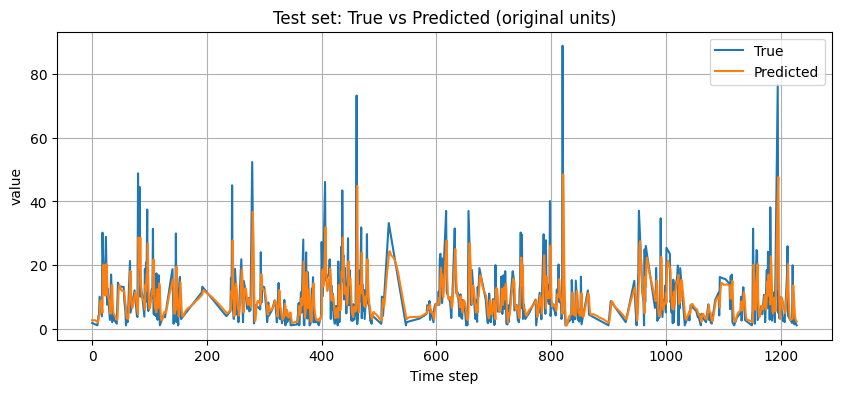

In [ ]:
# -----------------------
# 8) Load best model & evaluate on test set; produce metrics and plots
# -----------------------
assert os.path.exists(best_model_path), "Best model file not found. Something went wrong during training."

# Load the best model, explicitly providing the loss function
best_model = load_model(best_model_path, custom_objects={'mse': tf.keras.losses.MeanSquaredError()})
print("\nBest hyperparameter config:", best_config)
best_look_back = best_config['look_back']
# Recreate sequences using best_look_back to get train/test sets
X_all, y_all = create_sequences(values, look_back=best_look_back, target_idx=0)
n_seq = len(X_all)
n_test_seq = int(n_seq * test_size)
n_train_seq = n_seq - n_test_seq
X_train, y_train = X_all[:n_train_seq], y_all[:n_train_seq]
X_test, y_test = X_all[n_train_seq:], y_all[n_train_seq:]

# Evaluate
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

# inverse scale for target column to get original units
# We scaled all numeric columns together; to invert only the target we need to construct full feature vectors
# Approach: for each predicted scalar y (scaled), replace target col in a zero-vector and inverse_transform
def inverse_transform_target(scaled_vals, target_index=0):
    # scaled_vals: array-like of shape (n,)
    n = len(scaled_vals)
    dummy = np.zeros((n, len(numeric_cols)))
    dummy[:, target_index] = scaled_vals
    inv = scaler.inverse_transform(dummy)[:, target_index]
    return inv

train_pred_inv = inverse_transform_target(train_pred.ravel())
test_pred_inv = inverse_transform_target(test_pred.ravel())
y_train_inv = inverse_transform_target(y_train.ravel())
y_test_inv = inverse_transform_target(y_test.ravel())

# Metrics
def metrics(true, pred):
    return {
        'MSE': float(mean_squared_error(true, pred)),
        'RMSE': float(math.sqrt(mean_squared_error(true, pred))),
        'MAE': float(mean_absolute_error(true, pred))
    }

train_metrics = metrics(y_train_inv, train_pred_inv)
test_metrics = metrics(y_test_inv, test_pred_inv)
print("\nTrain metrics (original units):", train_metrics)
print("Test metrics (original units):", test_metrics)

# Plot test true vs pred (original units)
plt.figure(figsize=(10,4))
plt.plot(y_test_inv, label='True')
plt.plot(test_pred_inv, label='Predicted')
plt.title("Test set: True vs Predicted (original units)")
plt.xlabel("Time step")
plt.ylabel(target_col)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# -----------------------
# 9) Save final model and scaler (already saved best model), also export scaler and other artifacts
# -----------------------
final_model_path = 'final_lstm_savedmodel.h5'
best_model.save(final_model_path)
scaler_out = 'minmax_scaler.pkl'  # already saved earlier
print(f"Final model saved to {final_model_path} and scaler at {scaler_out}")

Final model saved to final_lstm_savedmodel.h5 and scaler at minmax_scaler.pkl


In [ ]:
# -----------------------
# 10) Use saved model to predict next N future steps (recursive forecasting)
# -----------------------
# We'll predict next n_future steps (choose 30 or same as test size)
n_future = min(30, max(1, n_test_seq))  # at most 30 steps or test size
print(f"\nGenerating recursive forecast for next {n_future} steps using the saved model...")

# We need the last 'best_look_back' scaled values to start the recursion
last_window = values[-best_look_back:].copy()  # shape (look_back, n_features)
future_preds_scaled = []
cur_window = last_window.copy()

for i in range(n_future):
    x_input = cur_window.reshape((1, cur_window.shape[0], cur_window.shape[1]))
    scaled_pred = best_model.predict(x_input)[0,0]
    future_preds_scaled.append(scaled_pred)
    # roll window and append predicted target (we'll append to target column and keep other features as last known)
    next_row = cur_window[-1].copy()
    next_row[0] = scaled_pred  # update target_col (index 0)
    cur_window = np.vstack([cur_window[1:], next_row])

future_preds_inv = inverse_transform_target(np.array(future_preds_scaled))

# Prepare a DataFrame for the forecast results
if date_col is not None:
    last_date = working.index[-1]
    future_dates = [last_date + timedelta(days=i+1) for i in range(n_future)]
    forecast_df = pd.DataFrame({ 'date': future_dates, f'predicted_{target_col}': future_preds_inv })
else:
    forecast_df = pd.DataFrame({ f'predicted_{target_col}': future_preds_inv })

print("\nForecast (next steps):")
display(forecast_df)

forecast_csv = 'next_forecast.csv'
forecast_df.to_csv(forecast_csv, index=False)
print(f"Forecast saved to {forecast_csv}")

# Save scaler and model paths for user's use
print("\nFiles you can download from the Colab environment:")
for p in [csv_path, final_model_path, scaler_out, results_csv, forecast_csv]:
    print(" -", p)

# Show top of results DataFrame
display(results_df.head())

# Final message
print("\nPipeline finished. You now have:")
print(" - Preprocessed & scaled data (in memory)")
print(f" - Best model saved at: {final_model_path}")
print(f" - Hyperparameter search results at: {results_csv}")
print(f" - Forecast CSV at: {forecast_csv}")
print(f" - Scaler at: {scaler_out}")


Generating recursive forecast for next 30 steps using the saved model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━

,date,predicted_value
0,2023-12-26,1.945462
1,2023-12-27,2.374046
2,2023-12-28,2.868776
3,2023-12-29,3.397451
4,2023-12-30,3.941007
5,2023-12-31,4.480973
6,2024-01-01,5.021558
7,2024-01-02,5.540691
8,2024-01-03,6.037044
9,2024-01-04,6.503352


Forecast saved to next_forecast.csv

Files you can download from the Colab environment:
 - Tiruppur_RFD.csv
 - final_lstm_savedmodel.h5
 - minmax_scaler.pkl
 - hyperparam_search_results.csv
 - next_forecast.csv


,trial,config,val_loss,val_mae,train_loss,train_mae,model_path
2,3,"{'look_back': 30, 'units': 16, 'layers': 2, 'd...",0.003299,0.031350,0.002506,0.026114,trial_model_2.h5
3,4,"{'look_back': 7, 'units': 100, 'layers': 1, 'd...",0.003302,0.031036,0.002485,0.026485,trial_model_3.h5
4,5,"{'look_back': 21, 'units': 32, 'layers': 2, 'd...",0.003308,0.032138,0.002732,0.029055,trial_model_4.h5
5,6,"{'look_back': 60, 'units': 50, 'layers': 2, 'd...",0.003339,0.031837,0.002303,0.024391,trial_model_5.h5
11,12,"{'look_back': 30, 'units': 64, 'layers': 1, 'd...",0.003354,0.032515,0.002595,0.027729,trial_model_11.h5



Pipeline finished. You now have:
 - Preprocessed & scaled data (in memory)
 - Best model saved at: final_lstm_savedmodel.h5
 - Hyperparameter search results at: hyperparam_search_results.csv
 - Forecast CSV at: next_forecast.csv
 - Scaler at: minmax_scaler.pkl
